In [1]:
# ¿Cuántas nuevas matrículas de vehículos eléctricos se esperan en los próximos seis meses y cuándo podría alcanzar su pico la adopción mensual?

# Las matrículas son un proxy de adopción tecnológica: no representan necesariamente compradores únicos ni permiten atribuir cambios a una política específica.

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

source = json.loads(Path("../data/source.json").read_text(encoding="utf-8"))
adoption = pd.read_csv("../data/us_ev_registrations_monthly.csv", parse_dates=["date"])
adoption["registrations_thousands"] = (
    adoption["bev_registrations_thousands"] + adoption["phev_registrations_thousands"]
)
adoption["cumulative_registrations_thousands"] = adoption["registrations_thousands"].cumsum()
adoption.head()

,date,bev_registrations_thousands,phev_registrations_thousands,registrations_thousands,cumulative_registrations_thousands
0,2020-10-01,25.8,8.8,34.6,34.6
1,2020-11-01,27.6,8.2,35.8,70.4
2,2020-12-01,38.8,9.6,48.4,118.8
3,2021-01-01,18.2,6.2,24.4,143.2
4,2021-02-01,26.9,9.0,35.9,179.1


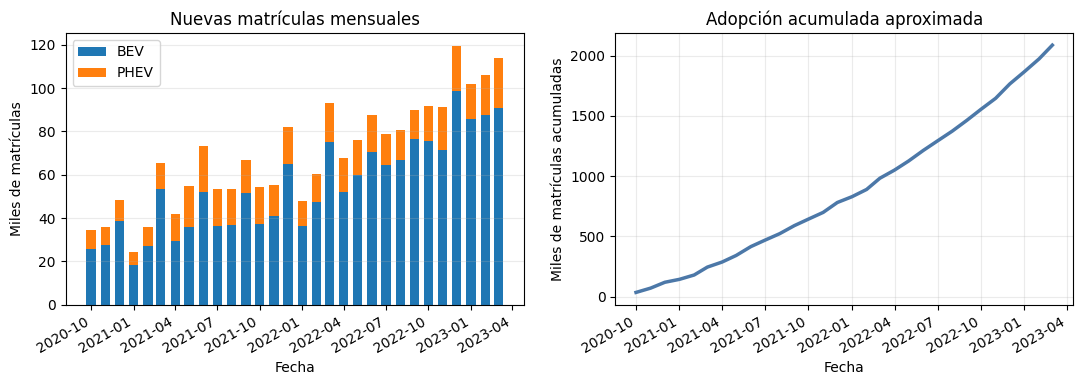

In [2]:
# La evidencia inicial muestra las dos tecnologías y evita confundir la serie mensual con su acumulado.

figure, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(
    adoption["date"],
    adoption["bev_registrations_thousands"],
    width=20,
    label="BEV",
)
axes[0].bar(
    adoption["date"],
    adoption["phev_registrations_thousands"],
    bottom=adoption["bev_registrations_thousands"],
    width=20,
    label="PHEV",
)
axes[0].set(
    title="Nuevas matrículas mensuales",
    xlabel="Fecha",
    ylabel="Miles de matrículas",
)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

axes[1].plot(
    adoption["date"],
    adoption["cumulative_registrations_thousands"],
    color="#4c78a8",
    linewidth=2.5,
)
axes[1].set(
    title="Adopción acumulada aproximada",
    xlabel="Fecha",
    ylabel="Miles de matrículas acumuladas",
)
axes[1].grid(alpha=0.25)
figure.autofmt_xdate()
plt.show()

In [3]:
# Se reservan los últimos seis meses para comprobar el pronóstico; el modelo no puede evaluarse con los mismos datos que utilizó para aprender.

training = adoption.iloc[:-6].copy()
evaluation = adoption.iloc[-6:].copy()
training["period"] = "entrenamiento"
evaluation["period"] = "evaluación"

print(f"Entrenamiento: {training['date'].min():%Y-%m} a {training['date'].max():%Y-%m}")
print(f"Evaluación: {evaluation['date'].min():%Y-%m} a {evaluation['date'].max():%Y-%m}")

Entrenamiento: 2020-10 a 2022-09
Evaluación: 2022-10 a 2023-03


In [4]:
# Bass representa la adopción acumulada mediante innovación, imitación y un mercado potencial; sus parámetros se ajustan únicamente con el tramo de entrenamiento.

def bass_cumulative(month, innovation, imitation, market_potential):
    decay = np.exp(-(innovation + imitation) * month)
    return market_potential * (1 - decay) / (1 + imitation / innovation * decay)

training_month = np.arange(1, len(training) + 1)
parameters, _ = curve_fit(
    bass_cumulative,
    training_month,
    training["cumulative_registrations_thousands"],
    p0=(0.01, 0.1, training["cumulative_registrations_thousands"].iloc[-1] * 4),
    bounds=([1e-5, 1e-5, training["cumulative_registrations_thousands"].iloc[-1]], [1, 3, 50_000]),
    maxfev=50_000,
)
innovation, imitation, market_potential = parameters

pd.DataFrame(
    [{"innovación": innovation, "imitación": imitation, "mercado_potencial_miles": market_potential}]
).round(3)

,innovación,imitación,mercado_potencial_miles
0,0.008,0.06,4600.584


In [5]:
# La línea base conserva la última matrícula observada; permite decidir si la dinámica de adopción añade poder predictivo real.

month = np.arange(1, len(adoption) + 1)
bass_cumulative_forecast = bass_cumulative(month, innovation, imitation, market_potential)
bass_monthly_forecast = np.diff(np.r_[0, bass_cumulative_forecast])

forecast = adoption[["date", "registrations_thousands", "cumulative_registrations_thousands"]].copy()
forecast["bass_monthly_forecast_thousands"] = bass_monthly_forecast
forecast["bass_cumulative_forecast_thousands"] = bass_cumulative_forecast
forecast["naive_monthly_forecast_thousands"] = training["registrations_thousands"].iloc[-1]
forecast["period"] = np.where(forecast["date"].isin(evaluation["date"]), "evaluación", "entrenamiento")

evaluation_forecast = forecast.loc[forecast["period"] == "evaluación"].copy()
metrics = pd.DataFrame(
    [
        {
            "model": "Bass",
            "mae_thousands": np.mean(abs(evaluation_forecast["registrations_thousands"] - evaluation_forecast["bass_monthly_forecast_thousands"])),
        },
        {
            "model": "Último valor",
            "mae_thousands": np.mean(abs(evaluation_forecast["registrations_thousands"] - evaluation_forecast["naive_monthly_forecast_thousands"])),
        },
    ]
).sort_values("mae_thousands")
metrics.round(2)

,model,mae_thousands
1,Último valor,14.20
0,Bass,17.74


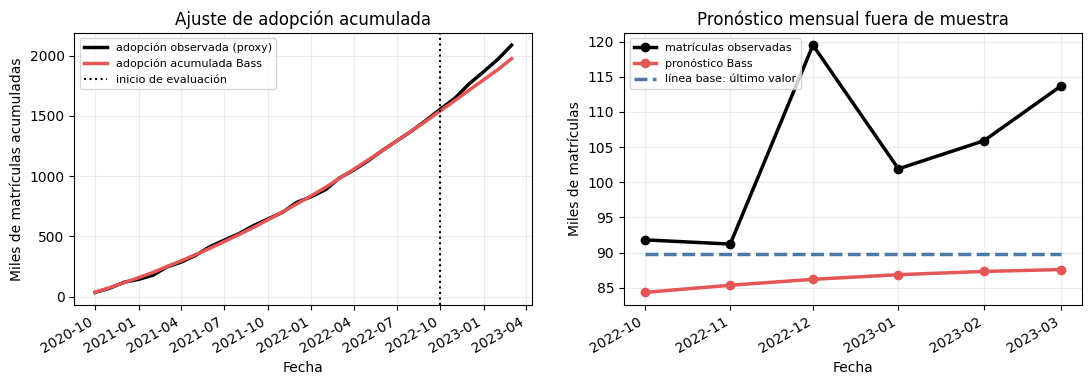

In [6]:
# La comparación final separa el ajuste acumulado de la calidad del pronóstico mensual posterior al corte.

figure, axes = plt.subplots(1, 2, figsize=(13, 4))
cutoff_date = evaluation["date"].iloc[0]

axes[0].plot(
    forecast["date"],
    forecast["cumulative_registrations_thousands"],
    color="black",
    linewidth=2.5,
    label="adopción observada (proxy)",
)
axes[0].plot(
    forecast["date"],
    forecast["bass_cumulative_forecast_thousands"],
    color="#e45756",
    linewidth=2.5,
    label="adopción acumulada Bass",
)
axes[0].axvline(cutoff_date, color="black", linestyle=":", label="inicio de evaluación")
axes[0].set(
    title="Ajuste de adopción acumulada",
    xlabel="Fecha",
    ylabel="Miles de matrículas acumuladas",
)
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].plot(
    evaluation_forecast["date"],
    evaluation_forecast["registrations_thousands"],
    color="black",
    marker="o",
    linewidth=2.5,
    label="matrículas observadas",
)
axes[1].plot(
    evaluation_forecast["date"],
    evaluation_forecast["bass_monthly_forecast_thousands"],
    color="#e45756",
    marker="o",
    linewidth=2.5,
    label="pronóstico Bass",
)
axes[1].plot(
    evaluation_forecast["date"],
    evaluation_forecast["naive_monthly_forecast_thousands"],
    color="#4c78a8",
    linestyle="--",
    linewidth=2.5,
    label="línea base: último valor",
)
axes[1].set(
    title="Pronóstico mensual fuera de muestra",
    xlabel="Fecha",
    ylabel="Miles de matrículas",
)
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)
figure.autofmt_xdate()
plt.show()

In [7]:
# Se preservan las evidencias que permiten revisar el pronóstico, el criterio de comparación y los supuestos.

submission_dir = Path("../submission")
forecast.to_csv(submission_dir / "adoption_forecast.csv", index=False)
metrics.to_csv(submission_dir / "model_metrics.csv", index=False)
figure.savefig(submission_dir / "adoption_forecast.png", dpi=150, bbox_inches="tight")

assumptions = {
    "source": source,
    "training_end": training["date"].max().strftime("%Y-%m-%d"),
    "evaluation_start": evaluation["date"].min().strftime("%Y-%m-%d"),
    "model": "Bass diffusion model fitted to cumulative registrations",
    "limitation": "Bass does not represent monthly seasonality, supply constraints, regulation, prices, or causal effects.",
}
(submission_dir / "model_assumptions.json").write_text(json.dumps(assumptions, indent=2), encoding="utf-8")


796